In [1]:
import h5py
import timeit
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import signal
from scipy import stats
from pylab import *
from matplotlib import cm
from scipy.stats import norm
from scipy.signal import welch
from scipy.signal import csd
from scipy.signal import correlate
from scipy.fft import fft
from scipy.integrate import trapz
from scipy.integrate import cumtrapz
from scipy.integrate import romb
from matplotlib.backends.backend_pdf import PdfPages
from tempfile import mkdtemp
import os.path as path
from statistics import mean
from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)

plt.style.use('classic')
mpl.rc("figure", facecolor="white")

# Data Import

Change Directory to Compressed Data File Location

In [2]:
exp_name = '4K GEN2HG'

Lock-in amplifier frequencies

In [3]:
f_lockin1 = 4.993017E6
f_lockin2 = 5.505658500E+6 - 2.8
kappa_1 = 0.00164284
kappa_2 = 0.00159284
Q1 = 4.2E7
Q2 = 4.2E7
dt=0.01

Zsquid_5C = 257604
Zsquid_3B = 363360
Zsquid_3C = 396523.297
Zsquid_run0_3B = 363360

Zsquid_1 = Zsquid_3C
Zsquid_2 = Zsquid_3B

In [4]:
data_name = 'run4'

In [5]:
os.chdir('C:/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/' + exp_name +'/'+data_name)

In [6]:
f=h5py.File(data_name+'.hdf5','r')

OSError: Unable to open file (unable to open file: name = 'run4.hdf5', errno = 22, error message = 'Invalid argument', flags = 0, o_flags = 0)

In [ ]:
list(f.keys())

In [ ]:
channel_1X=f['1X/Data'][:100000]
channel_1Y=f['1Y/Data'][:100000]
channel_2X=f['2X/Data'][:100000]
channel_2Y=f['2Y/Data'][:100000]

In [35]:
datasize=len(channel_1X)
nl1 = 100
nl2 = datasize//2**16
nfft = nl2
sc1 = 'density'
fs_rate=100

# PSDs and Strain Sensitivty

In [ ]:
f_welch_1X, S_welch_1X = welch(
        (channel_1X), fs=fs_rate, nperseg=nl2, #noverlap=nl1,
        detrend=None, scaling=sc1, window='hanning')


In [ ]:
f_welch_1Y, S_welch_1Y = welch(
        (channel_1Y), fs=fs_rate, nperseg=nl2, #noverlap=nl1,
        detrend=None, scaling=sc1, window='hanning')

In [ ]:
f_welch_2X, S_welch_2X = welch(
        (channel_2X), fs=fs_rate, nperseg=nl2, #noverlap=nl1,
        detrend=None, scaling=sc1, window='hanning')

In [ ]:
f_welch_2Y, S_welch_2Y = welch(
        (channel_2Y), fs=fs_rate, nperseg=nl2, #noverlap=nl1,
        detrend=None, scaling=sc1, window='hanning')

PSD of SQUID Output Voltage

In [ ]:
fig, axes = plt.subplots(1,1, figsize=(13,8))
axes.plot(f_welch_1X[5:],np.sqrt(S_welch_1X[5:]), 'b', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz?)")
axes.plot(f_welch_1Y[5:],np.sqrt(S_welch_1Y[5:]), 'r', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz?)")

axes.plot(f_welch_2X[5:],np.sqrt(S_welch_2X[5:]), 'g', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz?)")
axes.plot(f_welch_2Y[5:],np.sqrt(S_welch_2Y[5:]), 'k', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz?)")

axes.legend(loc=0,fontsize=16)

#axes.grid(True)
#axes.grid(True)

# axes.set_xscale('log')
# axes.set_yscale('log')
#axes.legend()
plt.xlim(0.1, 10)
# plt.ylim(0,1)
axes.set_xlabel(r'Fourier Frequency (Hz)', fontsize=25)
axes.set_ylabel(r'PSD ($\:\mu\mathrm{V}/\sqrt{\mathrm{Hz}}$)', fontsize=25)

plt.setp(axes.get_xticklabels(), rotation='horizontal', fontsize=24)
plt.setp(axes.get_yticklabels(), rotation='horizontal', fontsize=24)
plt.tight_layout()

pp = 'PSD.pdf'
plt.savefig(pp, format='pdf', dpi=600)


In [15]:
channel_2X

<HDF5 dataset "Data": shape (802000000,), type "<f8">

Normalise peak to 4K nyquist noise limit. peak would be at this value if not for changes to SQUID gain

In [16]:
Vpeak_nyquist_1 =  3.13948 #3C Mode
# Vpeak_nyquist_1 =  ----- #5C Mode
Vpeak_nyquist_2 =  3.13948 #3B Mode
Vpeak_1 = np.max(np.sqrt(S_welch_1X[20:]))
Vpeak_2 = np.max(np.sqrt(S_welch_2X[20:]))

Squid_loss_ch1 = Vpeak_nyquist_1/Vpeak_1
Squid_loss_ch2 = Vpeak_nyquist_2/Vpeak_2

Squid_loss_ch1, Squid_loss_ch2

(6.521461313614529, 5.996010261340249)

In [17]:
f_channel1=f_welch_1X[list(S_welch_1X).index(max(S_welch_1X[3:]))]
f_channel2=f_welch_2Y[list(S_welch_2Y).index(max(S_welch_2Y[3:]))]

In [18]:
f_channel1, f_channel2

(2.918911189053157, 1.874865137135583)

In [19]:
np.sqrt(0.2)

0.4472135954999579

# Parameters

Need to be updated manually based on which run

In [20]:

fs_rate=100
h0=0.00054635
trap=0.848
H0=2.2*10**(-18)

fr1=f_lockin1+f_channel1
omega1=2*np.pi*fr1
omega_ch1=2*np.pi*f_channel1
tau1=Q1/omega1

fr2=f_lockin2+f_channel2
omega2=2*np.pi*fr2
omega_ch2=2*np.pi*f_channel2
tau2=Q2/omega2


In [21]:
Si_1X=(S_welch_1X)*(10**(-6))**2*((Zsquid_1)**(-2))
Si_1Y=(S_welch_1Y)*(10**(-6))**2*((Zsquid_1)**(-2))
Si_2X=(S_welch_2X)*(10**(-6))**2*((Zsquid_2)**(-2))
Si_2Y=(S_welch_2Y)*(10**(-6))**2*((Zsquid_2)**(-2))

In [22]:
Sp_2 = Si_2X*3.0
Sp_1 = Si_1X*2.9

Pdiss_1 = trapz(Sp_1, f_welch_1X + f_lockin1)
Pdiss_2 = trapz(Sp_2, f_welch_2X + f_lockin2)

kb = 1.38064852E-23

Pdiss_1*tau1/kb, Pdiss_2*tau2/kb

(2.0319738682918835, 3.117777888092144)

In [23]:
np.max(np.sqrt(Si_2X**2+Si_2Y**2))

6.140284406401774e-20

Spectral Displacement Density

In [24]:
Sx_1X=Si_1X*((1/(kappa_1*2*np.pi*(fr1+f_welch_1X))))**2
Sx_1Y=Si_1Y*((1/(kappa_1*2*np.pi*(fr1+f_welch_1Y))))**2
Sx_2X=Si_2X*((1/(kappa_2*2*np.pi*(fr2+f_welch_2X))))**2
Sx_2Y=Si_2Y*((1/(kappa_2*2*np.pi*(fr2+f_welch_2Y))))**2


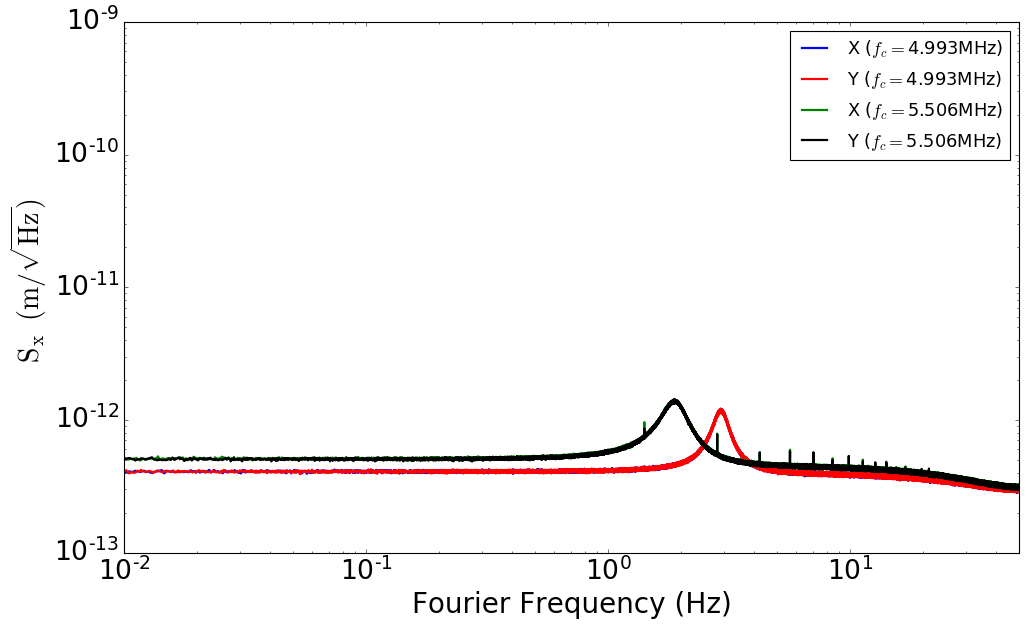

In [25]:
fig, axes = plt.subplots(1,1, figsize=(13,8))
axes.plot(f_welch_1X,np.sqrt(Si_1X), 'b', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")
axes.plot(f_welch_1Y,np.sqrt(Si_1Y), 'r', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")

axes.plot(f_welch_2X,np.sqrt(Si_2X), 'g', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")
axes.plot(f_welch_2Y,np.sqrt(Si_2Y), 'k', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")

axes.legend(loc=0,fontsize=16)

#axes.grid(True)
#axes.grid(True)

axes.set_xscale('log')
axes.set_yscale('log')
#axes.legend()
plt.xlim(0.01,50)
#plt.ylim(10**-17,10**-15)

axes.set_xlabel(r'Fourier Frequency (Hz)', fontsize=25)
axes.set_ylabel(r'  $\mathrm{S_x}\;\;(\mathrm{m}/\sqrt{\mathrm{Hz}})$ ', fontsize=25)

plt.setp(axes.get_xticklabels(), rotation='horizontal', fontsize=24)
plt.setp(axes.get_yticklabels(), rotation='horizontal', fontsize=24)


fig.tight_layout()


In [26]:
np.max(Si_2X)

2.581742111778131e-20

Spectral Strain Sensitivty via Transfer Function (See Mathematica Notebook)

Transfer Function

In [27]:
def trans1(w):
    return np.absolute(((-w)**2*h0*trap/2)/((w*1j)**2+(w*1j)/tau1+omega1**2))
def trans2(w):
    return np.absolute(((-w)**2*h0*trap/2)/((w*1j)**2+(w*1j)/tau2+omega2**2))

In [28]:
# converts fft of voltage series to fft of strain series
def voltstodisp_1(x,f):
    Si=(x)*(10**(-6))*((1.2*10**6)**(-1))
    Sx=Si*((1/(k*(f)*1j)))
    return Sx

def voltstodisp_2(x,f):
    Si=(x)*(10**(-6))*((1.2*10**6)**(-1))
    Sx=Si*((1/(k*(f)*1j)))
    return Sx

In [29]:
def voltstodisp_PSD_1(x,f): #converts PSD of voltage series to PSD of strain series
    Si=(x)*(10**(-6))**2*((1.2*10**6)**(-2))
    Sx=Si*((1/(k*(f))))**2
    return Sx

def voltstodisp_PSD_2(x,f): #converts PSD of voltage series to PSD of strain series
    Si=(x)*(10**(-6))**2*((1.2*10**6)**(-2))
    Sx=Si*((1/(k*(f))))**2
    return Sx

In [30]:
Hx_1X=np.array(list(map(trans1,2*np.pi*(f_welch_1X+f_lockin1))))
Hx_1Y=np.array(list(map(trans1,2*np.pi*(f_welch_1Y+f_lockin1))))
Hx_2X=np.array(list(map(trans2,2*np.pi*(f_welch_2X+f_lockin2))))
Hx_2Y=np.array(list(map(trans2,2*np.pi*(f_welch_2Y+f_lockin2))))

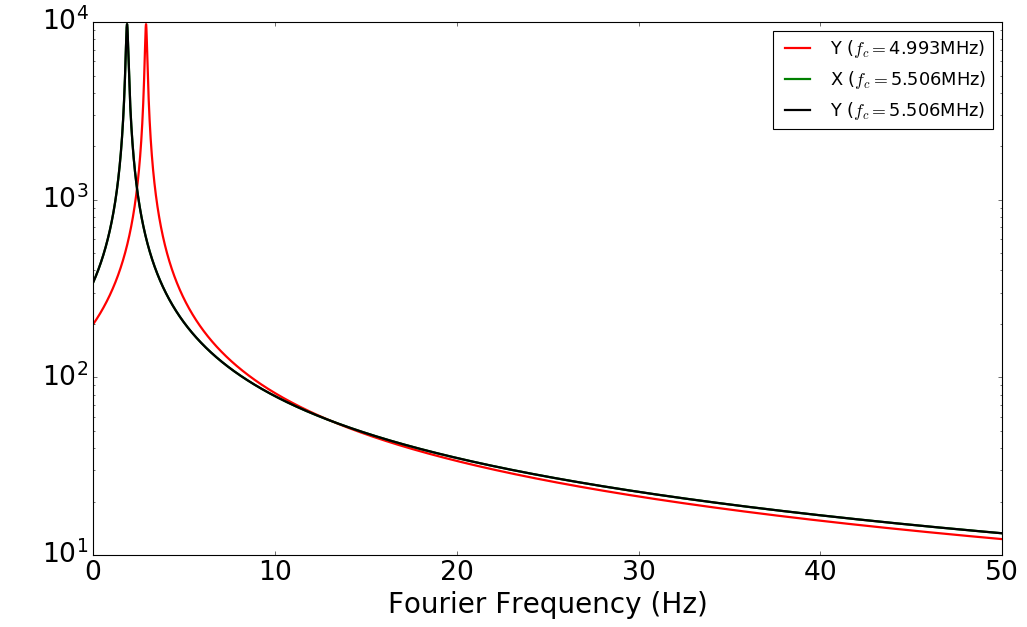

In [31]:
fig, axes = plt.subplots(1,1, figsize=(13,8))
# axes.plot(f_welch_1X,Hx_1X, 'b', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")# 
axes.plot(f_welch_1Y,Hx_1Y, 'r', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")

axes.plot(f_welch_2X,Hx_2X, 'g', linewidth=2, label=r"X ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")
axes.plot(f_welch_2Y,Hx_2Y, 'k', linewidth=2, label=r"Y ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")

axes.legend(loc=0,fontsize=16)

#axes.grid(True)
#axes.grid(True)

# axes.set_xscale('log')
axes.set_yscale('log')
#axes.legend()
#plt.xlim(1,50)
#plt.ylim(10**-17,10**-15)

axes.set_xlabel(r'Fourier Frequency (Hz)', fontsize=25)
axes.set_ylabel(r'  ', fontsize=25)

plt.setp(axes.get_xticklabels(), rotation='horizontal', fontsize=24)
plt.setp(axes.get_yticklabels(), rotation='horizontal', fontsize=24)


fig.tight_layout()


In [32]:
h_1X=np.sqrt(Sx_1X)/Hx_1X
h_1Y=np.sqrt(Sx_1Y)/Hx_1Y
h_2X=np.sqrt(Sx_2X)/Hx_2X
h_2Y=np.sqrt(Sx_2Y)/Hx_2Y

In [33]:
f_proj = [5.505e+6,101.0e+6]
h_proj = [9.0e-22,9.0e-23]

C:\Users\21958742\Anaconda3\lib\site-packages\ipykernel_launcher.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


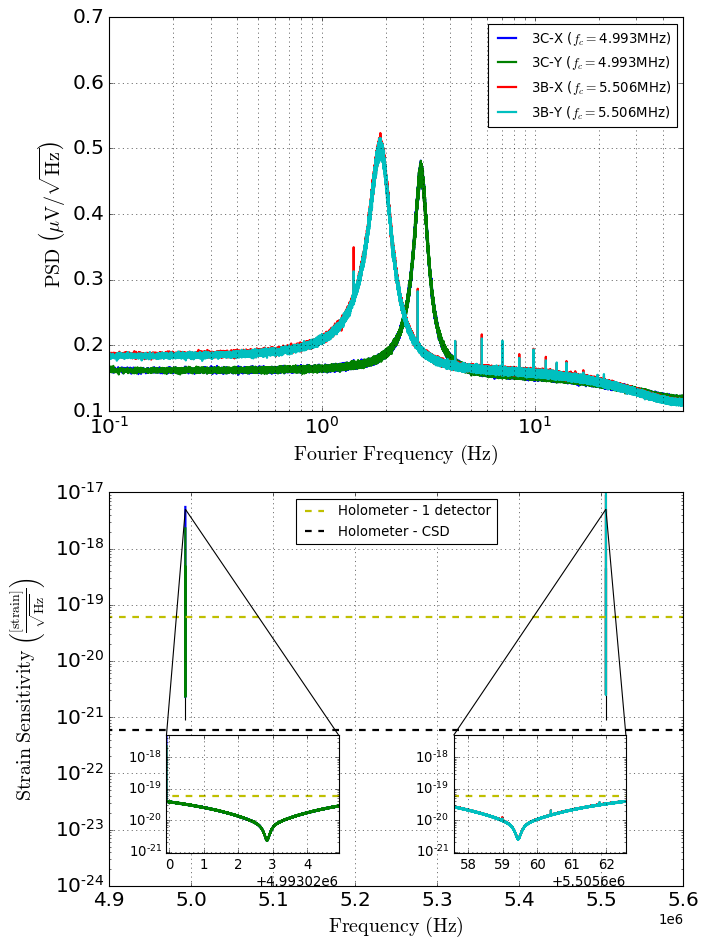

In [34]:
fig, ax = plt.subplots(2,1, figsize=(9,12))

axes=ax[1]
ax0 = ax[0]

ax0.plot(f_welch_1X[5:],np.sqrt(S_welch_1X[5:]), linewidth=2, label=r"3C-X ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")
ax0.plot(f_welch_1Y[5:],np.sqrt(S_welch_1Y[5:]), linewidth=2, label=r"3C-Y ($f_c = $" +str(format(f_lockin1/10**6,'1.3f'))+ "MHz)")

ax0.plot(f_welch_2X[5:],np.sqrt(S_welch_2X[5:]), linewidth=2, label=r"3B-X ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")
ax0.plot(f_welch_2Y[5:],np.sqrt(S_welch_2Y[5:]), linewidth=2, label=r"3B-Y ($f_c = $" +str(format(f_lockin2/10**6,'1.3f'))+ "MHz)")

# ax0.set_yscale('log')
ax0.set_xscale('log')
ax0.set_xlim(0.1,50)
ax0.set_ylim(0.1,0.7)
ax0.grid(True,'both')
ax0.legend(loc=0,fontsize=12)

ax0.set_xlabel(r'$\mathrm{Fourier~Frequency~(Hz)}$', fontsize=18)
ax0.set_ylabel(r'$\mathrm{ASD}~\left(\mu\mathrm{V}/\sqrt{\mathrm{Hz}}\right)$', fontsize=18)

plt.setp(ax0.get_xticklabels(), rotation='horizontal', fontsize=18)
plt.setp(ax0.get_yticklabels(), rotation='horizontal', fontsize=18)

axes.plot(f_welch_1X+fr1,h_1X, linewidth=2)
axes.plot(f_welch_1Y+fr1,h_1Y, linewidth=2)

axes.plot(f_welch_2X+fr2,h_2X, linewidth=2)
axes.plot(f_welch_2Y+fr2,h_2Y, linewidth=2)


f_holo = np.linspace(1.0e+6,13e+6,100)
axes.plot(f_holo, np.full(len(f_holo),6.0E-20), linewidth=2.0, color = 'y',linestyle = '--', label = 'Holometer - 1 detector')
axes.plot(f_holo, np.full(len(f_holo),6.0E-22), linewidth=2.0, color = 'k', linestyle = '--', label = 'Holometer - CSD')



axes.grid(True)

# axes.set_xscale('log')
axes.set_yscale('log')
#axes.legend()
plt.xlim(4.9e6,5.6e6)
plt.ylim(10**-24,10**-17)

axes.set_xlabel(r'$\mathrm{Frequency~(Hz)}$', fontsize=18)
axes.set_ylabel(r'$\mathrm{Strain~Sensitivity}~\left(\frac{[\mathrm{strain}]}{\sqrt{\mathrm{Hz}}}\right)$', fontsize=18)

plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))

plt.setp(axes.get_xticklabels(), rotation='horizontal', fontsize=18)
plt.setp(axes.get_yticklabels(), rotation='horizontal', fontsize=18)


# axins = inset_axes(axes, width="70%", height="60%",
#                    bbox_to_anchor=(.49, .1, .5, .6),
#                    bbox_transform=axes.transAxes, loc=4)

axinset = plt.axes([0,0,1,1])
# Manually set the position and relative size of the inset axes within ax1
ip = InsetPosition(axes, [0.6,0.0825,0.3,0.3])
axinset.set_axes_locator(ip)
mark_inset(axes, axinset, loc1=1, loc2=2)

axinset.plot(f_welch_2X+fr2,h_2X, linewidth=2, color = 'r')
axinset.plot(f_welch_2Y+fr2,h_2Y, linewidth=2, color = 'c')
axinset.plot(f_holo, np.full(len(f_holo),6.0E-20), linewidth=2.0, color = 'y', linestyle = '--', label = 'Holometer - 1 detector')

axinset.set_yscale('log')

axinset.set_ylim(9.0e-22,5.0e-18)
axinset.set_xlim(fr2,fr2+5)

axinset.get_xticklabels()

axinset.grid(True)

axinset2 = plt.axes([0,0,1,0.99])
# Manually set the position and relative size of the inset axes within ax1
ip2 = InsetPosition(axes, [0.1,0.0825,0.3,0.3])
axinset2.set_axes_locator(ip2)

axinset2.plot(f_welch_1X+fr1,h_1X, linewidth=2, color = 'b')
axinset2.plot(f_welch_1Y+fr1,h_1Y, linewidth=2, color = 'g')
axinset2.plot(f_holo, np.full(len(f_holo),6.0E-20), linewidth=2.0, color = 'y', linestyle = '--', label = 'Holometer - 1 detector')

axinset2.set_yscale('log')

axinset2.set_ylim(9.0e-22,5.0e-18)
axinset2.set_xlim(fr1,fr1+5)

axinset2.get_xticklabels()

axinset2.grid(True)

mark_inset(axes, axinset2, loc1=1, loc2=2)


axes.legend(loc=9,fontsize=12)

plt.tight_layout()

pp = PdfPages('SensitivityPlot.pdf')
plt.savefig(pp, format='pdf', dpi=600)
pp.close()

In [51]:
with open(data_name+'-frequencies' + ".out", "w") as text_file:
    msg = "Run name: " + data_name
    text_file.write(msg + "\n")
    print(msg)
    msg = "Channel 1 is at " + str(f_channel1)
    text_file.write(msg +'\n')
    print(msg)
    msg = "channel 2 is at " + str(f_channel2)
    text_file.write(msg + '\n')
    print(msg)

Run name: run4
Channel 1 is at 2.9458631256384065
channel 2 is at 1.881511746680286


In [52]:
G = 10/(30*10**-6)/17.37 #locking amplifier only
kB = 1.3806488*10**-23 # Boltzmann constant 
KK = (10**-12)/kB/(4*(G**2))

In [53]:
G


19190.17463058914

In [55]:
6e-7/0.525

1.1428571428571428e-06